In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
ds = pd.read_csv('multi_feature_LR.csv')

In [51]:
ds.shape

(10000, 5)

In [52]:
ds.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [53]:
ds.sample(5)

,square_feet,num_rooms,age,distance_to_city(km),price
9819,2554.222301,3,45,27.219770,282735.551549
7884,2070.797893,2,13,5.577401,297192.070325
2488,2012.694210,4,6,29.651165,232090.411848
7818,1775.652159,6,42,21.050344,243406.712329
317,1844.866622,4,38,5.837250,267940.405379


In [54]:
ds = ds.rename(columns={'square_feet':'sq-ft' , 'num_rooms':'total_rooms' , 'distance_to_city(km)':'commute(km)'})

In [55]:
ds = ds.drop_duplicates()
ds = ds.dropna()

In [71]:
ds

,sq-ft,total_rooms,age,commute(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


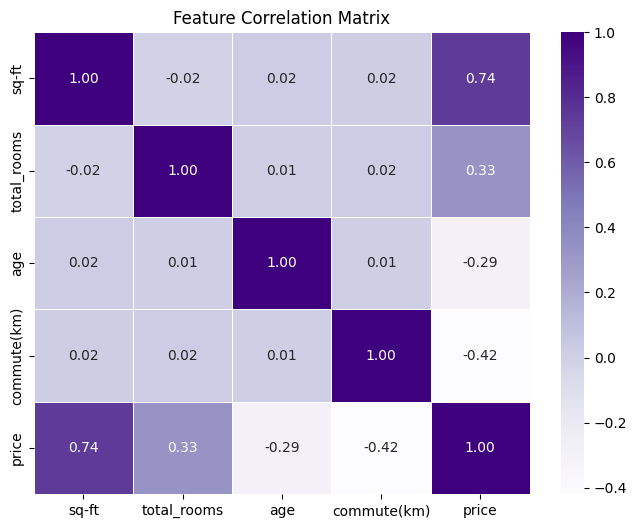

In [72]:
plt.figure(figsize=(8, 6))
correlation_matrix = ds[ds.columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Purples', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [57]:
num_cols = ['sq-ft', 'total_rooms', 'age', 'commute(km)', 'price']
for col in num_cols:
    Q1 = ds[col].quantile(0.25)
    Q3 = ds[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    ds = ds[(ds[col] >= lower_bound) & (ds[col] <= upper_bound)]

print(ds.shape)

(9873, 5)


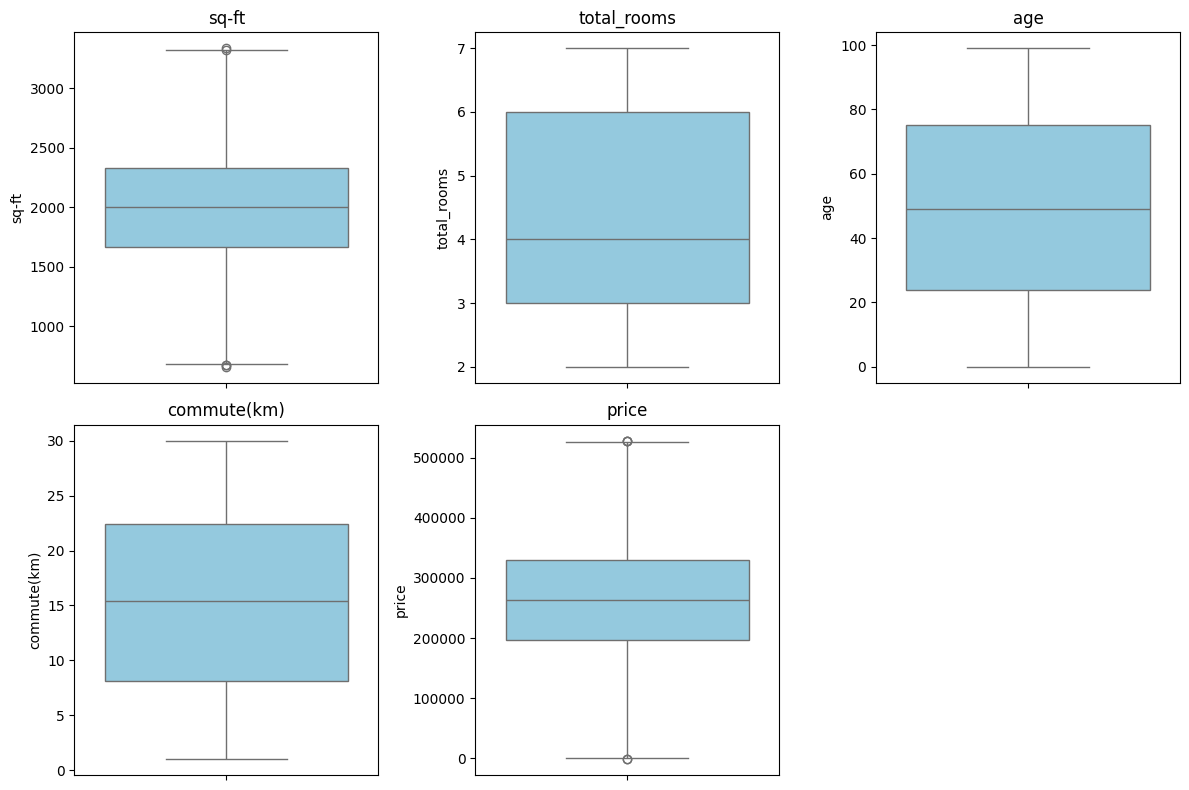

In [58]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=ds[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [59]:
X_raw = ds[['sq-ft', 'total_rooms', 'age', 'commute(km)']].values
y = ds['price'].values

sq_ft_col = X_raw[:, 0:1]
sq_ft_poly = np.hstack([sq_ft_col, sq_ft_col**2])
X_poly = np.hstack([sq_ft_poly, X_raw[:, 1:]]) 


X_mean = np.mean(X_poly, axis=0)
X_std = np.std(X_poly, axis=0)
X_scaled = (X_poly - X_mean) / X_std


m = X_scaled.shape[0]
X_b = np.hstack([np.ones((m, 1)), X_scaled])

Final Regularized Theta Parameters: [263100.74234232  51564.88069859  20329.08977275  34227.08020617
 -28940.39658709 -41475.99899116]
Final Cost: 208237441.2071


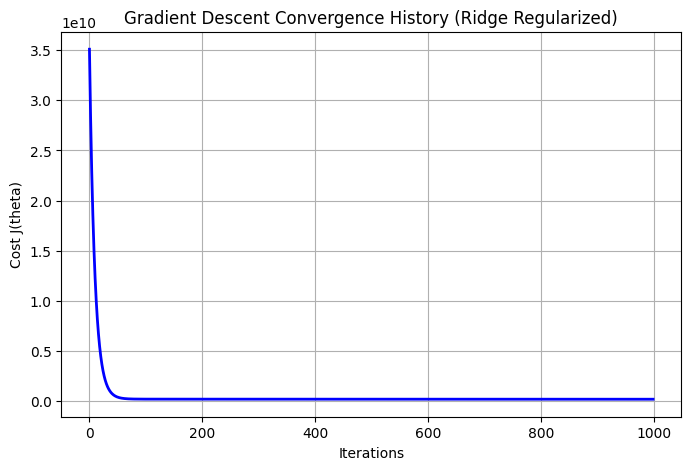

In [60]:
def compute_cost(X, y, theta, lambda_reg=0.0):
    m = len(y)
    predictions = X.dot(theta)
    reg_penalty = (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2) + reg_penalty
    return cost

def gradient_descent(X, y, theta, alpha, iterations, lambda_reg=0.0):
    m = len(y)
    cost_history = []
    
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y

        gradient_0 = (1 / m) * X[:, 0].dot(errors)
        gradient_weights = (1 / m) * X[:, 1:].T.dot(errors) + (lambda_reg / m) * theta[1:]
        
        gradient = np.hstack([[gradient_0], gradient_weights])
        theta = theta - alpha * gradient
        
        cost = compute_cost(X, y, theta, lambda_reg)
        cost_history.append(cost)
        
    return theta, cost_history

theta_init = np.zeros(X_b.shape[1])
alpha = 0.05
iterations = 1000
lambda_reg = 10.0

theta_final, cost_history = gradient_descent(X_b, y, theta_init, alpha, iterations, lambda_reg)

print("Final Regularized Theta Parameters:", theta_final)
print(f"Final Cost: {cost_history[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, color='b', lw=2)
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.title('Gradient Descent Convergence History (Ridge Regularized)')
plt.grid(True)
plt.show()

R² Score: 0.9543
RMSE: 20238.2283


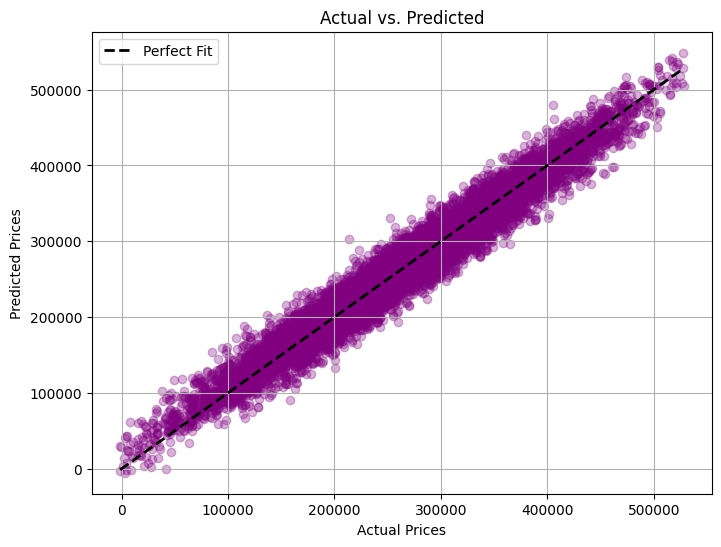

In [61]:
y_pred = X_b.dot(theta_final)

from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.3, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
model_artifact = { 
    'theta': theta_final,
    'X_mean': X_mean,
    'X_std': X_std,
    'lambda_reg': lambda_reg
}

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

print("Saved as 'house_price_model.pkl'!")

Saved as 'house_price_model.pkl'!


In [66]:
# %%
import pickle
import numpy as np

with open('house_price_model.pkl', 'rb') as f:
    artifact = pickle.load(f)

theta = artifact['theta']
X_mean = artifact['X_mean']
X_std = artifact['X_std']

user_input = np.array([[2000, 3, 15, 4.5]])

sq_ft_col = user_input[:, 0:1]
sq_ft_poly = np.hstack([sq_ft_col, sq_ft_col**2])
user_poly = np.hstack([sq_ft_poly, user_input[:, 1:]])

user_scaled = (user_poly - X_mean) / X_std

X_user_b = np.hstack([np.ones((1, 1)), user_scaled])
predicted_price = X_user_b.dot(theta)

print(f"Test Input -> \nSq-Ft: {user_input[0][0]}, \nRooms: {user_input[0][1]}, \nAge: {user_input[0][2]}, \nCommute: {user_input[0][3]}km")
print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Test Input -> 
Sq-Ft: 2000.0, 
Rooms: 3.0, 
Age: 15.0, 
Commute: 4.5km
Predicted House Price: $319,458.95
